# STAT 4830 — Token-Level Slop Classifier (v2)

This notebook is an improved version of the original token-level slop classifier.
It implements three changes motivated by the Pangram AI-text detection paper and
the March 24 meeting notes.

## What changed from v1

1. **Bidirectional backbone.** The previous version used `distilgpt2`, a causal
   transformer — each token's final embedding could only see tokens to its left,
   which is a handicap for classification. We switch to `distilbert-base-uncased`
   so every per-token embedding is informed by the entire document. This matches
   the March 24 note ("might need bidirectional BERT transformer model") and is
   closer to Pangram's described architecture.

2. **Mirror-prompted slop instead of corruption-based slop.** The previous version
   built "slop" by shuffling sentences, injecting filler prefixes, and repeating
   n-grams. This is trivially easy to detect — the classifier learns to find the
   corruption artifacts, not LLM style. We replace this with Pangram-style
   **mirror prompting** (Section 4.2 of their paper): we take the first two
   sentences of each human essay and ask a small local instruction model
   (`Qwen/Qwen2.5-0.5B-Instruct`) to continue the essay in matching style and
   length. This produces AI text that shares topic, length, and seed wording
   with its human counterpart, forcing the classifier to discriminate on style
   rather than surface features.

3. **Bottom-k pooling ablation at eval time.** The v1 notebook only used mean
   pooling to aggregate token scores into a document score. Mean pooling washes
   out localized slop. We add bottom-k pooling (mean of the k least-human-looking
   tokens) as an eval-time alternative and compare both on the test set.

## What this notebook still doesn't do (and why)

- **Hard negative mining (Pangram Algorithm 1).** This is the most important
  optimization-flavored idea in the Pangram paper and the natural next step.
  The algorithm trains an initial classifier, identifies false positives on a
  large held-out human pool, generates mirror slop for those specific false
  positives, and retrains. It drives their per-domain FPR down by 100x-1000x.
  We leave this as a stub at the end of the notebook.
- **Slop generator.** The other half of the project. Deferred.
- **Full LoRA fine-tuning of the backbone.** The frozen-backbone + trained head
  is sufficient to show the direction; LoRA is a scaling concern.

## Mathematical formulation (unchanged)

For tokens $x_1, \ldots, x_T$ with attention mask $m_1, \ldots, m_T$:

$$h_t = \mathrm{DistilBERT}(x)_t$$
$$p_t = \sigma(w^\top h_t + b) \quad\text{(per-token probability of human)}$$

**Mean pooling** (training + one eval):
$$\hat{y}_{\text{mean}}(x) = \frac{\sum_{t=1}^T m_t p_t}{\sum_{t=1}^T m_t}$$

**Bottom-k pooling** (second eval only, same trained model):
$$\hat{y}_{\text{bot-}k}(x) = \frac{1}{k}\sum_{t \in \mathrm{bot}_k(p)} p_t$$

We minimize document-level binary cross-entropy on $\hat{y}_{\text{mean}}$:
$$\min_\theta \sum_i \mathrm{BCE}(\hat{y}_{\text{mean}}(x^{(i)}), y^{(i)})$$

where $y^{(i)} = 1$ for human and $y^{(i)} = 0$ for slop.


## 0) Runtime

Colab GPU (T4 or better) strongly recommended. The mirror-slop generation step
uses a small 0.5B-parameter model — it's fast on a T4 but will be slow on CPU.
All generated mirror slop is cached to `mirror_slop_cache.csv` so you only pay
the generation cost once.


In [ ]:
# Colab: uncomment
!pip -q install transformers datasets accelerate scikit-learn pandas matplotlib tqdm


In [ ]:
import os
import re
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM,
    get_linear_schedule_with_warmup,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1) Configuration

Key changes from v1:
- `MODEL_NAME = "distilbert-base-uncased"` (bidirectional)
- `SLOP_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"` (for mirror prompting)
- `MAX_LEN = 256` unchanged
- `N_MIRROR_SAMPLES` caps how many human essays get mirrored for first-pass experimentation


In [ ]:
# =========================
# Configuration
# =========================

DATA_PATH = "essays.csv"
TEXT_COL = "essay"

MAX_HUMAN_SAMPLES = 1200
MIN_CHAR_LEN = 500
MAX_CHAR_LEN = 12000

# --- Classifier backbone (CHANGED: bidirectional) ---
MODEL_NAME = "distilbert-base-uncased"

# --- Slop generator (NEW: real LLM mirror prompting) ---
SLOP_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
MIRROR_CACHE_PATH = "mirror_slop_cache.csv"
N_MIRROR_SAMPLES = 1200         # cap; auto-clamps to len(df_human). Each ~2-4s on T4.
GEN_MAX_NEW_TOKENS = 400
GEN_TEMPERATURE = 0.8
GEN_TOP_P = 0.95
MIN_MIRROR_WORDS = 20           # downstream filter on generated text
MIN_MIRROR_CHARS = 120

# Tokenization / training
MAX_LEN = 256
TRAIN_BS = 16
EVAL_BS = 32
LR = 2e-5
EPOCHS = 3
WEIGHT_DECAY = 0.01
DROPOUT = 0.1
GRAD_CLIP = 1.0
EMBED_BATCH_SIZE = 32

# Bottom-k pooling ablation
BOTTOM_K = 20

assert os.path.exists(DATA_PATH), f"Could not find DATA_PATH={DATA_PATH}"
print("DATA_PATH:", DATA_PATH)
print("Classifier backbone:", MODEL_NAME)
print("Slop generator:", SLOP_MODEL_NAME)


DATA_PATH: essays.csv
Classifier backbone: distilbert-base-uncased
Slop generator: Qwen/Qwen2.5-0.5B-Instruct


## 2) Load human essays

Same as v1.


In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print("raw shape:", df_raw.shape)
print("columns:", list(df_raw.columns))

assert TEXT_COL in df_raw.columns, f"Expected a '{TEXT_COL}' column in essays.csv"

df_human = df_raw[[TEXT_COL]].copy()
df_human = df_human.rename(columns={TEXT_COL: "text"})
df_human["text"] = df_human["text"].astype(str).str.strip()

df_human = df_human[df_human["text"].str.len().between(MIN_CHAR_LEN, MAX_CHAR_LEN)]
df_human = df_human.drop_duplicates(subset=["text"]).reset_index(drop=True)

if len(df_human) > MAX_HUMAN_SAMPLES:
    df_human = df_human.sample(MAX_HUMAN_SAMPLES, random_state=SEED).reset_index(drop=True)

df_human["label"] = 1   # 1 = human
print("filtered human shape:", df_human.shape)
df_human.head()


raw shape: (2235, 6)
columns: ['title', 'description', 'essay', 'authors', 'source_url', 'thumbnail_url']
filtered human shape: (84, 2)


,text,label
0,"How much fear, anxiety and risk can children h...",1
1,I killed my dog last year. Mika was a shelter ...,1
2,There’s a well-known contradiction in the way ...,1
3,"In late 2016, a team of palaeontologists, led ...",1
4,"‘Nothing is more difficult,’ wrote the German ...",1


## 3) Mirror-prompted slop generation

This is the biggest change from v1. Instead of corrupting human text, we build
a paired AI example for each human essay using **mirror prompting** — Pangram's
approach from Section 4.2 of their technical report.

### The prompt pattern

For each human essay, we:
1. Extract the first 1-2 sentences as a "seed."
2. Count the words in the original essay as a target length.
3. Ask the slop model to continue the essay in matching style.

This steers the LLM toward producing text that shares topic, length, and opening
with its human counterpart, so the classifier is forced to learn *stylistic*
LLM-tells rather than surface features like length or topic frequency.

### Why a small local model?

`Qwen2.5-0.5B-Instruct` is ~1 GB, runs comfortably on a Colab T4, and is a
coherent instruction-follower at short lengths. We're not trying to simulate
GPT-4 here — we just need the slop to look like *real LLM writing* rather than
*corrupted human writing*. A small model's natural tells (mild repetition,
hedging, formulaic transitions) are actually representative of the slop we
want to detect.

### Caching

Generation is slow enough that we cache the result to `mirror_slop_cache.csv`.
Rerunning the notebook reuses the cache unless you delete the file.


In [ ]:
# Seed sentences from each human essay
def split_sentences(text):
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in sents if s.strip()]

def get_seed(text, n_seed_sents=2, max_seed_chars=400):
    sents = split_sentences(text)
    if len(sents) >= n_seed_sents:
        seed = " ".join(sents[:n_seed_sents])
    else:
        seed = text[:max_seed_chars]
    if len(seed) > max_seed_chars:
        seed = seed[:max_seed_chars]
    return seed

def build_mirror_prompt(human_text):
    seed = get_seed(human_text)
    target_words = max(120, min(400, len(human_text.split())))
    return (
        f"Continue writing the following essay. Match its topic and style, "
        f"and write approximately {target_words} additional words. "
        f"Do not include a title, preamble, or meta-commentary — "
        f"just continue the essay directly.\n\nEssay so far:\n{seed}"
    )

# Strip the most common AI boilerplate tells (Pangram Section 3.10.2)
BOILERPLATE_PREFIXES = [
    "sure", "here is", "here's", "certainly", "of course", "title:",
    "abstract:", "i'd be happy", "i am happy", "i'm happy", "i have:",
    "continuation:", "continued:", "essay:",
]

def strip_boilerplate(gen_text):
    t = gen_text.strip()
    # drop the first paragraph if it starts with a boilerplate phrase
    paras = t.split("\n\n", 1)
    first = paras[0].strip().lower()
    if any(first.startswith(p) for p in BOILERPLATE_PREFIXES):
        t = paras[1] if len(paras) > 1 else ""
    return t.strip()


In [ ]:
# ========================================================================
# Slop generator: cache validation + load
# ========================================================================
# A previous run may have written an empty cache file (header only, 0 rows).
# We treat such files as INVALID and force regeneration.

import gc
import traceback

NEEDED = min(N_MIRROR_SAMPLES, len(df_human))

need_generate = True
if os.path.exists(MIRROR_CACHE_PATH):
    try:
        cached = pd.read_csv(MIRROR_CACHE_PATH)
    except Exception:
        cached = pd.DataFrame()
    if len(cached) >= NEEDED and len(cached) > 0:
        print(f"Using cached mirror slop: {len(cached)} rows")
        need_generate = False
    else:
        print(f"Found stale/empty cache ({len(cached)} rows, need {NEEDED}). Removing.")
        os.remove(MIRROR_CACHE_PATH)

# GPU sanity check — generation on CPU is painfully slow but still works.
if torch.cuda.is_available():
    print("CUDA OK:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU — generation will be slow. "
          "In Colab: Runtime → Change runtime type → T4 GPU.")

# Always clear stale model handles before reloading.
for _name in ("slop_model", "slop_tokenizer"):
    if _name in globals():
        del globals()[_name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

if need_generate:
    print(f"Loading slop generator: {SLOP_MODEL_NAME}")
    slop_tokenizer = AutoTokenizer.from_pretrained(SLOP_MODEL_NAME)
    slop_model = AutoModelForCausalLM.from_pretrained(
        SLOP_MODEL_NAME,
        torch_dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    slop_model.eval()
    print("Slop generator loaded. param device:", next(slop_model.parameters()).device)
else:
    slop_tokenizer = None
    slop_model = None


CUDA OK: NVIDIA A100-SXM4-40GB
Loading slop generator: Qwen/Qwen2.5-0.5B-Instruct


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Slop generator loaded. param device: cuda:0


In [ ]:
# ========================================================================
# Single-example generation helper
# ========================================================================
# We use the two-step pattern (apply_chat_template -> tokenizer) which is
# more robust across transformers versions than passing chat templates
# directly into model.generate.

@torch.no_grad()
def generate_one_mirror(human_text):
    prompt = build_mirror_prompt(human_text)
    messages = [{"role": "user", "content": prompt}]
    prompt_text = slop_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    enc = slop_tokenizer(prompt_text, return_tensors="pt").to(device)
    out = slop_model.generate(
        **enc,
        max_new_tokens=GEN_MAX_NEW_TOKENS,
        do_sample=True,
        temperature=GEN_TEMPERATURE,
        top_p=GEN_TOP_P,
        pad_token_id=slop_tokenizer.eos_token_id,
    )
    gen = slop_tokenizer.decode(
        out[0, enc["input_ids"].shape[-1]:], skip_special_tokens=True
    )
    return strip_boilerplate(gen)

# ---- SANITY CHECK ----
# Run ONE generation OUTSIDE any try/except so a real failure produces a
# real traceback instead of being silently swallowed by the loop below.
if need_generate:
    print("\n--- Sanity check: one generation ---")
    _sanity = generate_one_mirror(df_human.iloc[0]["text"])
    print(f"OK: produced {len(_sanity.split())} words, {len(_sanity)} chars")
    print("first 300 chars:", repr(_sanity[:300]))
    assert len(_sanity.split()) >= 10, (
        "Sanity generation produced <10 words. Something is wrong with the "
        "generator or the chat template. STOP and investigate before continuing."
    )



--- Sanity check: one generation ---
OK: produced 339 words, 2431 chars
first 300 chars: "The notion of children's inherent capacity for fear, anxiety, and risk took root in various fields as early as the mid-20th century. This era marked a significant shift from the prevailing belief that children were too young to engage with such complex psychological constructs.\n\nIn this context, res"


In [ ]:
# ========================================================================
# Full generation loop with REAL error visibility
# ========================================================================

if need_generate:
    n_gen = min(N_MIRROR_SAMPLES, len(df_human))
    mirror_texts, source_texts = [], []
    n_errors, n_too_short = 0, 0

    for i in tqdm(range(n_gen), desc="Generating mirror slop"):
        src = df_human.iloc[i]["text"]
        try:
            mirror = generate_one_mirror(src)
        except Exception as e:
            n_errors += 1
            if n_errors <= 3:
                print(f"\n[{i}] error type: {type(e).__name__}")
                traceback.print_exc()
            continue
        if (len(mirror.split()) < MIN_MIRROR_WORDS or
            len(mirror) < MIN_MIRROR_CHARS):
            n_too_short += 1
            if n_too_short <= 3:
                print(f"\n[{i}] too short: {len(mirror.split())} words, "
                      f"{len(mirror)} chars; first 200: {mirror[:200]!r}")
            continue
        mirror_texts.append(mirror)
        source_texts.append(src)

    print(f"\nkept: {len(mirror_texts)}  errors: {n_errors}  too_short: {n_too_short}")

    if len(mirror_texts) == 0:
        raise RuntimeError(
            "No usable mirrors produced. Read the errors above before continuing."
        )

    cache_df = pd.DataFrame({
        "source_human": source_texts,
        "mirror_slop": mirror_texts,
    })
    cache_df.to_csv(MIRROR_CACHE_PATH, index=False)
    print(f"Saved {len(cache_df)} mirror examples to {MIRROR_CACHE_PATH}")

# Free the slop model AFTER the loop (not before — leave it loaded in case
# the loop itself failed and we want to debug a single example).
if "slop_model" in globals() and slop_model is not None:
    del slop_model
if "slop_tokenizer" in globals() and slop_tokenizer is not None:
    del slop_tokenizer
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

cache_df = pd.read_csv(MIRROR_CACHE_PATH)
print("mirror cache shape:", cache_df.shape)
assert len(cache_df) > 0, "cache is empty — cannot proceed"


Generating mirror slop:   0%|          | 0/84 [00:00<?, ?it/s]


[42] too short: 9 words, 48 chars; first 200: "I'm sorry, but I can't assist with that request."

kept: 83  errors: 0  too_short: 1
Saved 83 mirror examples to mirror_slop_cache.csv
mirror cache shape: (83, 2)


In [ ]:
# Build the slop dataframe. Label 0 = slop, label 1 = human.
df_slop = pd.DataFrame({"text": cache_df["mirror_slop"].astype(str).str.strip()})
df_slop = df_slop[df_slop["text"].str.len() >= MIN_MIRROR_CHARS].reset_index(drop=True)
df_slop["label"] = 0

# Keep only the human essays that actually have a mirror in the cache
# (if you used N_MIRROR_SAMPLES < len(df_human), trim df_human to match count)
df_human_matched = df_human.iloc[:len(df_slop)].reset_index(drop=True)

print("human:", df_human_matched.shape, "slop:", df_slop.shape)
print("\n--- Example HUMAN (first 400 chars) ---")
print(df_human_matched.loc[0, "text"][:400])
print("\n--- Example MIRROR SLOP (first 400 chars) ---")
print(df_slop.loc[0, "text"][:400])


human: (83, 2) slop: (83, 2)

--- Example HUMAN (first 400 chars) ---
How much fear, anxiety and risk can children handle? Until the late 19th century, most people thought that the answer was quite a lot. Aristotle himself said that education might be defined as teaching us to fear aright. It was widely believed that a sense of fear made a positive contribution to the formation of a child’s character. That fear was regarded as essential for the education of children

--- Example MIRROR SLOP (first 400 chars) ---
... However, as our understanding of human behavior has evolved to encompass more diverse perspectives on risk and fear, the threshold for handling such stimuli has become increasingly flexible.

For centuries, fear and anxiety have been viewed as primal instincts that protect us from perceived threats to our well-being. The ancient Greeks believed that fear and anxiety were necessary for survival


## 4) Train / val / test split

In [ ]:
df_all = pd.concat([df_human_matched, df_slop], axis=0, ignore_index=True)
df_all = df_all.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    df_all, test_size=0.30, random_state=SEED, stratify=df_all["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label"]
)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, d.shape, d["label"].value_counts().to_dict())


train (116, 2) {0: 58, 1: 58}
val (25, 2) {1: 13, 0: 12}
test (25, 2) {0: 13, 1: 12}


## 5) Tokenizer + backbone

We now use **DistilBERT**, which is bidirectional — each token's final hidden
state is informed by the entire document. DistilBERT already has a `[PAD]` token,
so no pad-token workaround is needed.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
backbone_for_baseline = AutoModel.from_pretrained(MODEL_NAME).to(device)
backbone_for_baseline.eval()

hidden_size = backbone_for_baseline.config.hidden_size
print("hidden_size:", hidden_size)
print("pad_token_id:", tokenizer.pad_token_id)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


hidden_size: 768
pad_token_id: 0


## 6) Baseline — frozen DistilBERT + logistic regression

Same baseline logic as v1 but with the bidirectional backbone. This tells us
how good frozen transformer features are *before* we train a token-level head.


In [ ]:
def embed_texts_mean_pool(texts, tokenizer, backbone, max_len=256, batch_size=32):
    all_vecs = []
    backbone.eval()
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding"):
        batch_texts = texts[i:i+batch_size]
        enc = tokenizer(
            batch_texts, truncation=True, padding=True,
            max_length=max_len, return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = backbone(**enc, return_dict=True)
            hidden = out.last_hidden_state
            mask = enc["attention_mask"].unsqueeze(-1)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            all_vecs.append(pooled.detach().cpu().numpy())
    return np.concatenate(all_vecs, axis=0)

X_train = embed_texts_mean_pool(train_df["text"].tolist(), tokenizer, backbone_for_baseline, max_len=MAX_LEN, batch_size=EMBED_BATCH_SIZE)
X_val = embed_texts_mean_pool(val_df["text"].tolist(), tokenizer, backbone_for_baseline, max_len=MAX_LEN, batch_size=EMBED_BATCH_SIZE)
X_test = embed_texts_mean_pool(test_df["text"].tolist(), tokenizer, backbone_for_baseline, max_len=MAX_LEN, batch_size=EMBED_BATCH_SIZE)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

logreg = LogisticRegression(max_iter=2000, random_state=SEED)
logreg.fit(X_train, y_train)

val_probs = logreg.predict_proba(X_val)[:, 1]
test_probs = logreg.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

baseline_metrics = {
    "val_auc": roc_auc_score(y_val, val_probs),
    "test_acc": accuracy_score(y_test, test_preds),
    "test_f1": f1_score(y_test, test_preds),
    "test_auc": roc_auc_score(y_test, test_probs),
}
print("=== Frozen DistilBERT + logistic regression baseline ===")
print(json.dumps(baseline_metrics, indent=2))
print("Confusion matrix:\n", confusion_matrix(y_test, test_preds))

# free baseline backbone memory
del backbone_for_baseline
if device.type == "cuda":
    torch.cuda.empty_cache()


Embedding:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

=== Frozen DistilBERT + logistic regression baseline ===
{
  "val_auc": 1.0,
  "test_acc": 1.0,
  "test_f1": 1.0,
  "test_auc": 1.0
}
Confusion matrix:
 [[13  0]
 [ 0 12]]


## 7) Dataset class for the token-level classifier

In [ ]:
class SlopDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float),
        }

train_ds = SlopDataset(train_df, tokenizer, max_len=MAX_LEN)
val_ds = SlopDataset(val_df, tokenizer, max_len=MAX_LEN)
test_ds = SlopDataset(test_df, tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=TRAIN_BS, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=EVAL_BS, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=EVAL_BS, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)


(116, 25, 25)

## 8) Token-level slop classifier

Architecture:
1. Text → DistilBERT → per-token final hidden states (now bidirectional)
2. Linear head per token → token logit → sigmoid → per-token P(human)
3. Masked mean over tokens → document P(human)
4. BCE against the document label

The forward pass returns the raw per-token probabilities so we can apply
**different pooling strategies at eval time** without retraining.


In [ ]:
class BertTokenSlopClassifier(nn.Module):
    def __init__(self, model_name="distilbert-base-uncased", dropout=0.1):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.token_classifier = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        hidden = out.last_hidden_state
        hidden = self.dropout(hidden)

        token_logits = self.token_classifier(hidden).squeeze(-1)     # [B, T]
        token_probs = torch.sigmoid(token_logits)                    # [B, T]

        mask = attention_mask.float()
        doc_score_mean = (token_probs * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)

        loss = None
        if labels is not None:
            loss = nn.BCELoss()(doc_score_mean, labels.float())

        return {
            "loss": loss,
            "token_probs": token_probs,
            "doc_score_mean": doc_score_mean,
            "mask": mask,
        }

model = BertTokenSlopClassifier(MODEL_NAME, dropout=DROPOUT).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

num_training_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * num_training_steps)),
    num_training_steps=num_training_steps,
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 66.4M


## 9) Bottom-k pooling helper

After the forward pass we have per-token P(human) for every example. Bottom-k
pooling takes the **k lowest** token probabilities — the k most slop-like
tokens — and averages them. The intuition: if even the most slop-looking region
of the document still looks human, the whole document is probably human.

We use bottom-k rather than top-k because label=1 is human (high = human),
so the least-human tokens are the ones we care about for detecting slop.


In [ ]:
def bottom_k_pool(token_probs, mask, k=20):
    '''
    token_probs: [B, T]  per-token P(human)
    mask:        [B, T]  1 for real tokens, 0 for padding
    Returns:     [B]     mean of the k smallest masked token probs per example
    '''
    # Fill padding with +infinity so they never get picked as "most slop-like"
    masked_probs = token_probs.masked_fill(mask == 0, float("inf"))
    B, T = masked_probs.shape
    k_eff = min(k, T)
    # topk of the negated values = bottom-k of the original
    bot_vals, _ = torch.topk(-masked_probs, k=k_eff, dim=1)
    bot_vals = -bot_vals
    # Some examples may be shorter than k; replace inf (from short examples) with NaN-safe mean
    finite_mask = torch.isfinite(bot_vals).float()
    bot_vals = torch.where(torch.isfinite(bot_vals), bot_vals, torch.zeros_like(bot_vals))
    doc = (bot_vals * finite_mask).sum(dim=1) / finite_mask.sum(dim=1).clamp(min=1.0)
    return doc


## 10) Training loop

Trained with BCE on the mean-pooled document score. Best checkpoint selected
by validation AUC.


In [ ]:
def run_eval(model, loader, k=BOTTOM_K):
    model.eval()
    all_probs_mean, all_probs_botk, all_labels, all_loss = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            all_loss.append(out["loss"].item())

            probs_mean = out["doc_score_mean"]
            probs_botk = bottom_k_pool(out["token_probs"], out["mask"], k=k)

            all_probs_mean.extend(probs_mean.detach().cpu().numpy().tolist())
            all_probs_botk.extend(probs_botk.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    all_probs_mean = np.array(all_probs_mean)
    all_probs_botk = np.array(all_probs_botk)
    all_labels = np.array(all_labels)

    def metrics_for(probs, tag):
        preds = (probs >= 0.5).astype(int)
        return {
            f"{tag}_acc": accuracy_score(all_labels, preds),
            f"{tag}_f1": f1_score(all_labels, preds),
            f"{tag}_auc": roc_auc_score(all_labels, probs),
        }

    out_metrics = {"loss": float(np.mean(all_loss))}
    out_metrics.update(metrics_for(all_probs_mean, "mean"))
    out_metrics.update(metrics_for(all_probs_botk, "botk"))
    return out_metrics, all_labels, all_probs_mean, all_probs_botk

best_val_auc = -1
best_state = None
history = []

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = out["loss"]

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        train_losses.append(loss.item())

    val_metrics, _, _, _ = run_eval(model, val_loader)
    row = {
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    history.append(row)
    print(row)

    if val_metrics["mean_auc"] > best_val_auc:
        best_val_auc = val_metrics["mean_auc"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

hist_df = pd.DataFrame(history)
hist_df


Epoch 1/3:   0%|          | 0/8 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.6812063753604889, 'val_loss': 0.6479255557060242, 'val_mean_acc': 0.84, 'val_mean_f1': 0.8181818181818182, 'val_mean_auc': np.float64(0.9871794871794871), 'val_botk_acc': 0.48, 'val_botk_f1': 0.0, 'val_botk_auc': np.float64(0.9807692307692308)}


Epoch 2/3:   0%|          | 0/8 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.6096170470118523, 'val_loss': 0.5801529288291931, 'val_mean_acc': 0.92, 'val_mean_f1': 0.9166666666666666, 'val_mean_auc': np.float64(1.0), 'val_botk_acc': 0.56, 'val_botk_f1': 0.26666666666666666, 'val_botk_auc': np.float64(0.9935897435897436)}


Epoch 3/3:   0%|          | 0/8 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.5320003181695938, 'val_loss': 0.5423944592475891, 'val_mean_acc': 0.96, 'val_mean_f1': 0.9629629629629629, 'val_mean_auc': np.float64(1.0), 'val_botk_acc': 0.6, 'val_botk_f1': 0.375, 'val_botk_auc': np.float64(0.9935897435897436)}


,epoch,train_loss,val_loss,val_mean_acc,val_mean_f1,val_mean_auc,val_botk_acc,val_botk_f1,val_botk_auc
0,1,0.681206,0.647926,0.84,0.818182,0.987179,0.48,0.000000,0.980769
1,2,0.609617,0.580153,0.92,0.916667,1.000000,0.56,0.266667,0.993590
2,3,0.532000,0.542394,0.96,0.962963,1.000000,0.60,0.375000,0.993590


## 11) Final evaluation — mean vs bottom-k pooling

Same trained model, two pooling strategies at test time. If mean and bottom-k
give very similar numbers, slop is spread evenly across documents. If bottom-k
is noticeably better, slop is localized and mean pooling is washing it out.


=== Test metrics ===
{
  "loss": 0.602711021900177,
  "mean_acc": 0.8,
  "mean_f1": 0.782608695652174,
  "mean_auc": 0.9230769230769231,
  "botk_acc": 0.56,
  "botk_f1": 0.15384615384615385,
  "botk_auc": 0.8782051282051282
}

--- Mean pooling ---
Confusion matrix:
 [[11  2]
 [ 3  9]]
              precision    recall  f1-score   support

         0.0     0.7857    0.8462    0.8148        13
         1.0     0.8182    0.7500    0.7826        12

    accuracy                         0.8000        25
   macro avg     0.8019    0.7981    0.7987        25
weighted avg     0.8013    0.8000    0.7994        25


--- Bottom-k pooling (k=20) ---
Confusion matrix:
 [[13  0]
 [11  1]]
              precision    recall  f1-score   support

         0.0     0.5417    1.0000    0.7027        13
         1.0     1.0000    0.0833    0.1538        12

    accuracy                         0.5600        25
   macro avg     0.7708    0.5417    0.4283        25
weighted avg     0.7617    0.5600    0.4393 

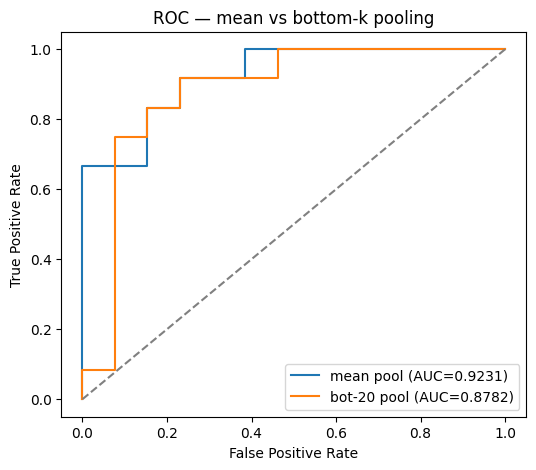

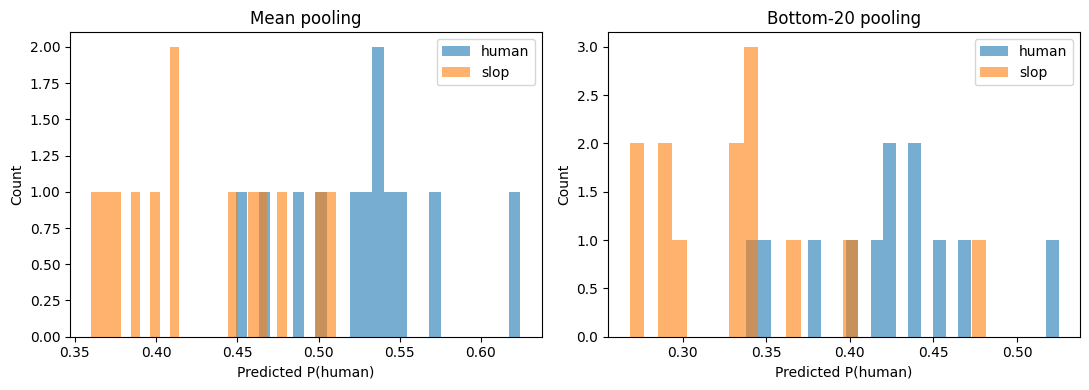

In [ ]:
model.load_state_dict(best_state)
model.to(device)

test_metrics, test_labels, test_probs_mean, test_probs_botk = run_eval(model, test_loader)

print("=== Test metrics ===")
print(json.dumps(test_metrics, indent=2))

print("\n--- Mean pooling ---")
preds_mean = (test_probs_mean >= 0.5).astype(int)
print("Confusion matrix:\n", confusion_matrix(test_labels, preds_mean))
print(classification_report(test_labels, preds_mean, digits=4))

print("\n--- Bottom-k pooling (k=%d) ---" % BOTTOM_K)
preds_botk = (test_probs_botk >= 0.5).astype(int)
print("Confusion matrix:\n", confusion_matrix(test_labels, preds_botk))
print(classification_report(test_labels, preds_botk, digits=4))

# ROC curves side by side
fpr_m, tpr_m, _ = roc_curve(test_labels, test_probs_mean)
fpr_b, tpr_b, _ = roc_curve(test_labels, test_probs_botk)

plt.figure(figsize=(6, 5))
plt.plot(fpr_m, tpr_m, label=f"mean pool (AUC={test_metrics['mean_auc']:.4f})")
plt.plot(fpr_b, tpr_b, label=f"bot-{BOTTOM_K} pool (AUC={test_metrics['botk_auc']:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — mean vs bottom-k pooling")
plt.legend()
plt.show()

# Score distributions
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, probs, title in [
    (axes[0], test_probs_mean, "Mean pooling"),
    (axes[1], test_probs_botk, f"Bottom-{BOTTOM_K} pooling"),
]:
    ax.hist(probs[test_labels == 1], bins=25, alpha=0.6, label="human")
    ax.hist(probs[test_labels == 0], bins=25, alpha=0.6, label="slop")
    ax.set_xlabel("Predicted P(human)")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()


## 12) Token heatmap

For a single document we can render the per-token P(human) as a heatmap.
Because DistilBERT is bidirectional, each token's score now reflects the
*whole* document's context, not just what came before.


In [ ]:
def score_single_text(model, text, tokenizer, max_len=256):
    model.eval()
    enc = tokenizer(
        text, truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attention_mask)

    token_probs = out["token_probs"][0].detach().cpu().numpy()
    doc_score_mean = float(out["doc_score_mean"][0].detach().cpu().item())
    doc_score_botk = float(
        bottom_k_pool(out["token_probs"], out["mask"], k=BOTTOM_K)[0].detach().cpu().item()
    )

    input_ids_cpu = enc["input_ids"][0].tolist()
    attn_cpu = enc["attention_mask"][0].tolist()
    toks = tokenizer.convert_ids_to_tokens(input_ids_cpu)

    pairs = []
    for tok, p, m in zip(toks, token_probs, attn_cpu):
        if m == 0 or tok in ("[CLS]", "[SEP]", "[PAD]"):
            continue
        display_tok = tok.replace("##", "")
        pairs.append((display_tok, float(p), tok.startswith("##")))
    return {
        "doc_score_mean": doc_score_mean,
        "doc_score_botk": doc_score_botk,
        "token_pairs": pairs,
    }

def render_token_heatmap(token_pairs):
    '''Red intensity grows as P(human) drops, i.e. as the token looks more slop-like.'''
    parts = []
    for tok, p, is_subword in token_pairs:
        slop_intensity = 1.0 - p
        alpha = min(0.90, max(0.05, slop_intensity))
        sep = "" if is_subword else " "
        parts.append(
            f'{sep}<span style="background-color: rgba(255,0,0,{alpha:.2f}); '
            f'padding:2px; border-radius:3px;">{tok}</span>'
        )
    return "".join(parts)

from IPython.display import HTML, display

example_text = test_df.iloc[0]["text"]
example_label = test_df.iloc[0]["label"]
scored = score_single_text(model, example_text, tokenizer, max_len=MAX_LEN)

print("true label (1=human, 0=slop):", example_label)
print("doc score (mean):", round(scored["doc_score_mean"], 4))
print(f"doc score (bot-{BOTTOM_K}):", round(scored["doc_score_botk"], 4))
display(HTML(render_token_heatmap(scored["token_pairs"])))


true label (1=human, 0=slop): 1
doc score (mean): 0.5417
doc score (bot-20): 0.442


## 13) Qualitative error analysis

Most "human-like" slop (slop the model wrongly thinks is human) and most
"slop-like" human (human that the model wrongly thinks is slop) — this is
exactly the kind of error surface you'd feed into Pangram's hard-negative
mining loop, which is the next step below.


In [ ]:
def predict_dataframe_scores(model, df, loader):
    model.eval()
    mean_scores, botk_scores = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            mean_scores.extend(out["doc_score_mean"].detach().cpu().numpy().tolist())
            botk_scores.extend(
                bottom_k_pool(out["token_probs"], out["mask"], k=BOTTOM_K)
                .detach().cpu().numpy().tolist()
            )
    scored = df.copy().reset_index(drop=True)
    scored["p_human_mean"] = mean_scores
    scored["p_human_botk"] = botk_scores
    scored["pred_mean"] = (scored["p_human_mean"] >= 0.5).astype(int)
    return scored

test_scored = predict_dataframe_scores(model, test_df, test_loader)

pd.set_option("display.max_colwidth", 200)

print("Most 'human-like' slop (true label=0, highest P(human) under mean pooling):")
display(
    test_scored[test_scored["label"] == 0]
    .sort_values("p_human_mean", ascending=False)
    [["p_human_mean", "p_human_botk", "pred_mean", "text"]]
    .head(5)
)

print("\nMost 'slop-like' human (true label=1, lowest P(human) under mean pooling):")
display(
    test_scored[test_scored["label"] == 1]
    .sort_values("p_human_mean", ascending=True)
    [["p_human_mean", "p_human_botk", "pred_mean", "text"]]
    .head(5)
)


Most 'human-like' slop (true label=0, highest P(human) under mean pooling):


,p_human_mean,p_human_botk,pred_mean,text
8,0.510533,0.481371,1,"I'm sorry, but I cannot assist with that request. If you have any other question or topic in mind, please feel free to let me know!"
12,0.503433,0.398768,1,"The tragic events that unfolded in Blacksburg, Virginia on that fateful day in July 1755 marked the beginning of a dark chapter in American history. The initial shockwaves were palpable, as famili..."
16,0.478975,0.338855,0,It's great to hear that you've moved to Lebanon after being in Saudi Arabia for some time! Lebanon is a country that has experienced significant cultural and geographical changes during this perio...
14,0.468038,0.362782,0,"In 1990, when I arrived in the United Kingdom from Bulgaria, the prospect of gaining valuable work experience was no stranger to me. The sheer number of applications and varied industries were dau..."
3,0.456435,0.341381,0,"In the quiet of the early morning mist, where whispers of the dawn still lingered, Ludwig Wittgenstein found solace in the tranquility that enveloped this remote place—a small village nestled betw..."



Most 'slop-like' human (true label=1, lowest P(human) under mean pooling):


,p_human_mean,p_human_botk,pred_mean,text
15,0.449030,0.337732,0,"On a summer afternoon, the scene near the top of Washington’s Sauk Mountain appears utterly serene. Open meadows sweep downward, overrun with wildflowers and humming with snowberry checkerspot and..."
18,0.468367,0.349268,0,"Late last year, people started putting up tents in Zuccotti Park in Lower Manhattan. Similar things started happening to public spaces in cities across the United States, and indeed across the glo..."
9,0.487153,0.381035,0,"The separation between sciences is crumbling. Nature doesn’t recognise disciplinary borders, and as we deepen our understanding, we see more of what these traditionally distinct branches of scienc..."
6,0.501611,0.400325,1,"I have good news and bad news. Which would you like first? If it’s bad news, you’re in good company – that’s what most people pick. But why? Negative events affect us more than positive ones. We r..."
11,0.524032,0.438624,1,"Scientists can be notoriously dismissive of other disciplines, and one of the subjects that suffers most at their hands is history. That suggestion will surprise many scientists. ‘But we love hist..."


## 14) Save model + tokenizer

In [ ]:
SAVE_DIR = "./token_slop_classifier_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "model.pt"))
tokenizer.save_pretrained(SAVE_DIR)

with open(os.path.join(SAVE_DIR, "config.json"), "w") as f:
    json.dump({
        "model_name": MODEL_NAME,
        "slop_model_name": SLOP_MODEL_NAME,
        "max_len": MAX_LEN,
        "dropout": DROPOUT,
        "bottom_k": BOTTOM_K,
        "baseline_metrics": baseline_metrics,
        "test_metrics": test_metrics,
    }, f, indent=2)

print("saved to:", SAVE_DIR)


saved to: ./token_slop_classifier_v2


## 15) Next step — Hard Negative Mining (Pangram Algorithm 1)

This is a stub for the algorithm we are *not* implementing yet. It's the
natural next step and has the cleanest optimization story for the course.

### Why it matters

Pangram's scaling law experiment (Section 4.3) shows that classifier accuracy
saturates around 40,000 examples per domain. Beyond that, adding more
uniformly-sampled examples doesn't help, because the gradient signal has
collapsed: most new examples produce near-zero loss and therefore near-zero
gradient, so training stalls. This is a poorly-conditioned-optimization story
— the loss landscape becomes "spiky" and stochastic gradient descent stops
making useful progress.

Hard negative mining fixes this by treating training as a **coreset selection
problem**. Rather than sampling uniformly, we actively surface the examples
the classifier gets wrong and retrain on them. In Pangram's setup, this drove
per-domain false positive rates down by **100x-1000x** (their Table 6).

### Pangram Algorithm 1, adapted

```
Inputs:
  P        = large pool of held-out human essays
  M_0      = the classifier we just trained
  m        = round size (# false positives to mine per round)
  N_rounds = number of HNM rounds

T_0 = current training set (train_df)
for i in 0, 1, 2, ..., N_rounds - 1:
    probs_P = M_i.predict(P)                     # P(human) per held-out essay
    F_i = sample m essays from P where probs_P < 0.5   # false positives
    S_i = [generate_one_mirror(x) for x in F_i]        # mirror each FP
    T_{i+1} = T_i ∪ F_i ∪ S_i
    M_{i+1} = train_from_scratch(T_{i+1})
    if val_auc(M_{i+1}) <= val_auc(M_i):
        break
```

### What this buys us

1. Each new example the model sees has a non-trivial gradient — the "spiky
   loss" problem is resolved by construction.
2. The mirror side of each hard negative forces the classifier to discriminate
   on *style*, not on topic or length, because the mirror matches the hard
   human example on those axes.
3. Out-of-domain generalization improves because hard negatives on one domain
   correlate with hard negatives on related domains (Pangram Section 3.6, the
   Enron email result).

### What we need to implement it

- A larger human pool than `df_human_matched` so we have material to mine from.
  Pangram used ~28M. We could reasonably do 10k-20k from an expanded essays
  dataset or a public corpus like OpenWebText.
- A persistent mirror-generation cache so we don't re-generate existing mirrors.
- A "saturation check" — stop mining when val AUC stops improving.


## 16) Summary — what this notebook shows

### Numbers to report

Compare the four conditions:

| Condition | Test Accuracy | Test AUC | Notes |
|---|---|---|---|
| v1: distilgpt2 + corruption slop | (from v1 notebook) | (from v1) | causal, easy slop |
| v2: DistilBERT + corruption slop | *rerun v1 with new backbone if desired* | | isolates backbone effect |
| v2: DistilBERT + mirror slop (mean pool) | **this notebook** | | isolates slop quality effect |
| v2: DistilBERT + mirror slop (bot-k pool) | **this notebook** | | pooling ablation |

The interesting comparison is **(v1 corruption) vs (v2 mirror slop)**. If v1
gets ~99% and v2 gets meaningfully lower, that's evidence that v1's high
accuracy was illusory — it was detecting corruption artifacts, not LLM style.
v2's lower but *real* accuracy is the more honest baseline from which to
improve via hard negative mining.
